In [10]:
import time
import os
#import mozuma
%load_ext autoreload
import cv2
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


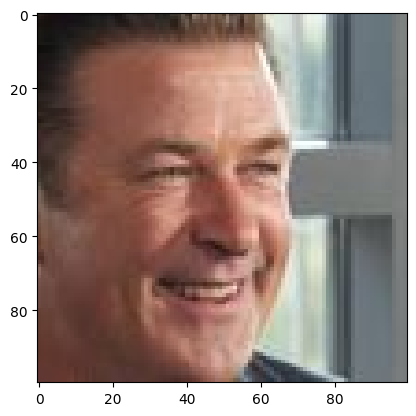

TypeError: gaussian_blur() got an unexpected keyword argument 'kernel'

In [14]:
# Testing convolution
im = cv2.imread("data/pubfig_small_flat/AlecBaldwin_222.jpg")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)
plt.show()
blur = torchvision.transforms.functional.gaussian_blur(torch.Tensor(im), kernel=(13, 13), sigma=[0.5, 0.5])
high_pass = cv2.subtract(im, blur)
plt.imshow(high_pass)
plt.show()

print("high pass is in range", np.min(high_pass), np.max(high_pass))
filtered_sum = np.mean(high_pass * im)
print(filtered_sum)

ModuleNotFoundError: No module named 'facedataset'

In [23]:
# Testing InsightFace
from src.insightface.recognition.arcface_torch.backbones import get_model

if_net = get_model("r50", fp16=False)
if_net.load_state_dict(torch.load("model_checkpoints/arcface_r50_ms1mv3.pth"))
if_net.eval()
if_net.to(torch.device("cuda"))

im = cv2.imread("data/pubfig_flat/Barack Obama_154.jpg")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
im = 2 * ((im / 255.0) - 0.5)
im = np.transpose(im, (2, 0, 1))
im = torch.Tensor(im).unsqueeze(0).to(torch.device("cuda"))
print(im.size())

emb = if_net(im)
print(emb.squeeze())


torch.Size([1, 3, 100, 100])
tensor([-0.9261,  0.4876,  0.1774, -0.2846, -0.8648,  0.4727, -0.1689, -0.2754,
         0.3388,  1.3417,  0.0517, -0.8443, -0.6875,  0.0854, -1.2536,  0.5010,
         0.6915, -0.3546, -0.1256,  0.2193,  0.9922, -0.1724, -0.2145,  0.3094,
        -0.4029, -1.1501, -0.7380, -0.6520, -1.3978, -0.6758, -0.3291, -0.1353,
        -0.6565, -0.5307,  1.3935, -0.7264,  0.2236,  0.5583, -0.3392, -0.4148,
         0.5392,  0.1875, -0.6550,  0.3008, -0.9680, -0.5651,  0.5077,  0.4128,
        -0.6627,  0.2689, -0.2745, -1.5532, -1.1820, -0.0220, -0.0477,  0.2119,
        -1.0378, -0.2309,  1.0671,  0.9477,  1.2641, -0.6647, -1.8245,  0.4115,
        -0.2791, -0.9162,  0.3993,  0.2430, -1.1846, -1.4371, -1.0733,  0.9781,
         0.5040,  1.2552, -0.1443, -0.3478, -0.1217,  0.2935, -0.5047, -0.4228,
        -1.1727,  0.4235, -0.3122, -0.9843,  0.1088, -0.1254, -0.1076, -0.0683,
        -1.1868,  0.0845,  0.4273,  0.0232, -0.6717, -1.0796,  0.1790, -1.1623,
         0.

In [6]:
start = time.perf_counter()
import shutil

num = 0
for path in os.listdir("data/pubfig83/Nicole Richie/"):
    total_path = "data/pubfig83/Nicole Richie/" + path
    try:
        emb = DeepFace.represent(total_path)
        print(emb)
        break
    except:
        print(num, "Face not found")
    num += 1
end = time.perf_counter()
print("Faces took", end - start, "seconds")
print("Average time:", (end - start) / num, "sec.")

0 Face not found
[{'embedding': [0.0, 0.0, 0.013487322930763683, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.12312239031468297, 0.0, 0.0, 0.0, 0.0, 0.013868773762704284, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0037894928002269374, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0077531827403972565, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02016837161514664, 0.0, 0.0, 0.0, 0.0, 0.018687955733295892, 0.0289375110000265, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.017607248313233917, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0017633854468013298, 0.0, 0.0, 0.012392332157883929, 0.0, 0.0, 0.008866709157559681, 0.0, 0.021705767162240278, 0.0, 0.0, 0.0, 0.0, 0.015889774551620946, 0.027542315501234958, 0.0, 0.016056667599238402, 0.07445983494989308, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.017818854867406222, 0.031412038296522206, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0113

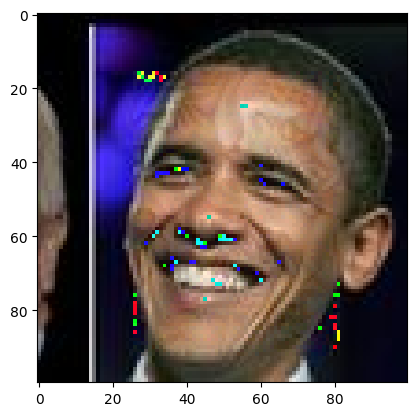

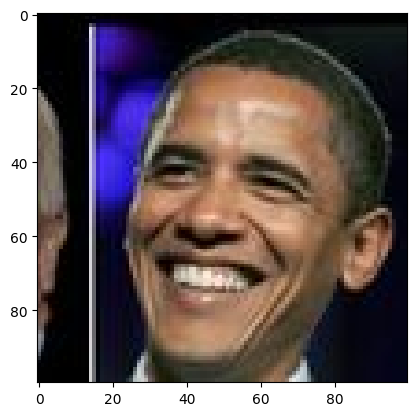

In [5]:
path = "Barack Obama_154"
im = cv2.imread("data/pubfig_cloaked/" + path + ".png")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)
plt.show()
im2 = cv2.imread("data/pubfig_flat/" + path + ".jpg")
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)
plt.imshow(im2)
plt.show()


In [11]:
import shutil
import os
for name in os.listdir("data/lfw-deepfunneled/lfw-deepfunneled"):
    print(name)
    for path in os.listdir("data/lfw-deepfunneled/lfw-deepfunneled/" + name + "/"):
        path_edit = path.replace("_", "")
        path_edit = path_edit[:-8] + "_" + path_edit[-8:]
        shutil.copyfile("data/lfw-deepfunneled/lfw-deepfunneled/" + name + "/" + path, "data/lfw_flat/" + path_edit)

Oscar_Bolanos
Imam_Samudra
Kaye_Young
Cemil_Cicek
Marta_Dominguz
Alfred_Ford
Dion_Glover
Annette_Bening
Tim_Howard
Jude_Law
Tassos_Papadopoulos
Jorma_Huhtala
Lee_Yeo-jin
Ramon_Santana
Cheryl_Tiegs
Ahmet_Demir
Klaus_Schwab
Nikolay_Davydenko
Lloyd_Richards
Ana_Sebastiao
Julie_Taymor
Zydrunas_Ilgauskas
Munir_Akram
Tubby_Smith
Takeshi_Kitano
Barry_Hinson
Ken_Kutaragi
Richard_Jewell
Aaron_Pena
Roger_Machado
David_Brinkley
Luther_Htu
Mark_Shapiro
Natasha_Lyonne
Deniz_Baykal
Robert_Stack
Joseph_Nacchio
Nicolas_Escude
Gwen_Stefani
Robert_F_Kennedy_Jr
Helen_Alvare
Guillermo_Monroy
Frank_Griswold
Dionigi_Tettamanzi
Jane_Russell
Warren_Granados
Gore_Vidal
Ian_Campbell
Vince_Gill
Melissa_Joan_Hart
Barbara_Brezigar
Darrell_Royal
Lou_Reed
Herb_Brooks
Thaksin_Shinawatra
Yusuf_Misbac
Jennifer_Love_Hewitt
Buzz_Hargrove
Trent_Lott
Sofyan_Dawood
Lubomir_Zaoralek
Stacey_Jones
Alberto_Fujimori
Dan_Dickau
Frank_Taylor
Emyr_Jones_Parry
Tom_Craddick
Tom_Miller
Gary_Bettman
Amanda_Beard
Elizabeth_Hill
Hun_Sen


Jim_Nochols
Lucy_Liu
Hilmi_Akin_Zorlu
Jana_Henke
Michael_Kors
Milo_Djukanovic
Kwame_Kilpatrick
Joy_Lee_Sadler
Jessica_Lange
Paul_Lo_Duca
Roger_King
Joy_Bryant
David_Collenette
Victor_Kraatz
Robin_Williams
Warren_Beatty
John_Timoney
Brian_Campbell
Derek_King
James_Hill
Andrzej_Tyszkiewicz
Maria_Bello
Felipe_Perez_Roque
Jake_Brace
Debbie_Reynolds
Jay_Leno
Mike_Holmgren
Hilmi_Ozkok
Celine_Dion
Linda_Sanchez
Mariana_Ohata
Bob_Bowlsby
Mona_Ayoub
Rachel_Leigh_Cook
Donald_Pettit
Oliver_Neuville
Cari_Davis
Robin_Wright_Penn
Alan_Trammell
Harold_Scott
Claude_Jorda
Ed_Smart
Tatyana_Tomashova
Ted_Washington
Charlie_Deane
Kim_Jin-sun
Johnnie_Lynn
Katie_Boone
Louisa_Baileche
Ibrahim_Al-Marashi
Steny_Hoyer
Gian_Marco
Hank_Bass
Michael_Taylor
Michelle_Chiklis
Miranda_Gaddis
Abid_Hamid_Mahmud_Al-Tikriti
Eliza_Dushku
Troy_Aikman
Uzi_Even
Francis_Crick
Gary_Bergeron
Shawn_Marion
Christina_Sawaya
Anne_Krueger
Steve_Stirling
Nelson_Acosta
Mary_Bono
Keith_Brown
Michael_Donovan
Tony_Parker
Daniel_Barenboim


Sally_Kirkland
Bob_Riley
Hu_Jintao
Alexandra_Jackson
Natalie_Stewart
Henry_Hilow
George_Allen
Paula_Zahn
Marc_Shaiman
Eli_Broad
Randy_Johnson
Jesse_Jackson
Mufti_Mohammad_Syed
Ronald_White
Kenneth_Bowersox
Ray_Sherman
Brittany_Snow
Khum_Bahadur_Khadka
Elizabeth_Hurley
Gregor_Gysi
Chris_Moore
Chang_Saio-yue
Sanja_Papic
Jim_Taylor
Holly_Hunter
Bob_Curtis
Anil_Ramsook
Katie_Smith
Fred_Eckhard
Toshihiko_Fukui
Marilyn_Monroe
Satnarine_Sharma
Vicente_Fox
Kim_Dong-tae
Azra_Akin
Frederick_Madden
Ilham_Aliev
Dan_Wheldon
SJ_Twu
John_Nimmo
Jim_Beattie
Alan_Mulally
Andy_Garcia
Edward_Seaga
Carlos_Juarez
Miyako_Miyazaki
Imelda_Marcos
Brian_Billick
Masja_Juel
Troy_Polamalu
James_Hughes
Nicholoas_DiMarzio
Ms_Dynamite
Rebecca_Romijn-Stamos
Alan_Jackson
Ashley_Judd
Jodie_Kidd
Nancy_Demme
Rupert_Grint
Phil_Vassar
Matt_Welsh
Carlos_Iturgaitz
Alfredo_di_Stefano
Mahathir_Mohamad
Buddy_Ryan
Marcus_Gronholm
Michel_Duclos
Cherry_Jones
Leslie_Ann_Woodward
Hugh_Grant
Josh_Evans
Paola_Espinoza
Dusty_Baker
Richar

Larry_Brown
Keira_Knightley
Robin_Cook
Roger_Corbett
Douglas_Meester
Mark_Everson
Richard_Dreyfuss
Jonathan_Edwards
Ester_Canadas
John_Bond
Geoffrey_Davis
Ricardo_Mayorga
Alan_Ball
Steve_McManaman
Tom_DeLay
Rogelio_Ramos
Salman_Rushdie
Carlos_Vives
Sharon_Stone
James_Meredeth
Edward_Albee
Roman_Abramovich
John_McCallum
Gordana_Grubin
Charles_Bronson
Lene_Espersen
Billy_Beane
Gianni_Agnelli
David_Wolf
Bill_Pryor
Oracene_Williams
George_Bovell
Erick_Barkley
Robert_Kipkoech_Cheruiyot
Saadi_Gadhafi
Mark_Martin
Simona_Hradil
Alexander_Payne
Megan_Mullally
Aidan_Quinn
John_Bolton
John_Taylor
Zahir_Shah
Mario_Austin
Brett_Boone
Jessica_Lynch
Timothy_McVeigh
Jack_Nicholson
Brandon_Webb
Tracee_Treadwell
Sophie
Greg_Kinnear
MC_Hammer
Don_Lake
Tyler_Grillo
Juergen_Chrobog
Laura_Hernandez
Geraldo_Rivera
Martin_McGuinness
Harvey_Fierstein
Demetrius_Ferraciu
Woodrow_Stanley
Marcelo_Rios
Richard_Rodriguez
Austin_Kearns
Kathryn_Morris
Lane_Odom
Akhmed_Zakayev
Jacques_Villeneuve
Madonna
Tom_Rouen
Kurt_

Ross_Verba
Lee_Nam-shin
Kevin_Spacey
Sheila_Fraser
Gerry_Parsky
Katerina_Smrzova
Rodney_Rempt
Sean_Astin
Bustam_A_Zedan_Aljanabi
Dave_Barr
Stefano_Accorsi
Nora_Ephron
Alecos_Markides
Jim_Cantalupo
Tom_Coverdale
Laszlo_Kovacs
Princess_Masako
Manfred_Reyes_Villa
Sally_Clark
Luis_Guzman
Jack_LaLanne
George_Lucas
Armando_Avila_Panchame
Mikhail_Kasyanov
Zavad_Zarif
Freda_Black
Jason_Clermont
Calvin_Harrison
Anneli_Jaatteenmaki
Joan_Laporta
Bob_Newhart
Robert_Weitzel
Hans_Eichel
Jason_Keep
Svend_Robinson
Cole_Chapman
Victor_Hanescu
Ibrahim_Jaafari
Jack_Goodman
Mary_Jo_Myers
Jennifer_Lopez
Barzan_al-Tikriti
Kristen_Breitweiser
Elizabeth_Berkeley
Joseph_Galante
Rogelio_Montemayor
Flavia_Delaroli
Pascal_Lamy
Brooke_Adams
Danny_Glover
Paul_Henderson
Meghann_Shaughnessy
Denzel_Washington
David_Leahy
Eurico_Guterres
Laurence_Fishburne
Mike_Babcock
David_Dodge
Mark_Broxmeyer
David_Hyde_Pierce
Dionne_Warwick
Jose_Jose
James_Kelly
Dave_McNally
Takeo_Fukui
Federico_Fellini
Alberto_Acosta
Talisa_Soto
M

Dan_Ackroyd
Bernard_Lord
Elizabeth_Shue
Billy_Andrade
Chuck_Finley
Edward_Belvin
Theresa_Gattung
Bernardo_Segura
Fred_Durst
Kosuke_Kitajima
Arthur_Martinez
Gong_Ruina
Martin_Landau
James_Phelps
Lawrence_Vito
Wilbert_Foy
Amram_Mitzna
Boutros_Boutros_Ghali
Kyle_Shewfelt
Thomas_Weston
Lela_Rochon
Tzipora_Obziler
Enrique_Haroldo_Gorriaran_Merlo
Fabricio_Oberto
George_McCloud
Rainer_Schuettler
Frank_Abagnale_Jr
Steven_Tyler
Ari_Fleischer
Anne_McLellan
Bob_Colvin
Ferenc_Madl
Drew_Gooden
Cristina_Fernandez
Bertie_Ahern
Hisham_Halawi
Jennifer_Capriati
BJ_Habibie
Svetoslav_Todorov
Ben_Affleck
Tommy_Tubberville
Festus_Mogae
Abba_Eban
Gavin_Degraw
Kelli_White
Paul_Lockhart
Marcelo_Bielsa
Roberto_Guaterroma
Richard_Lennon
Robert_Schuller
Martin_Sheen
Bryan_Adams
Jorge_Marquez-Ruarte
Gunter_Pleuger
Ana_Guevara
Phil_Mickelson
Stefanie_De_Roux
Brian_Heidik
Camille_Colvin
Ruben_Sierra
Teruaki_Masumoto
Karl-Heinz_Rummenigge
Jean_Chretien
Eliott_Spitzer
Janet_Thorpe
Theresa_May
Nancy_Smith
Wim_Duisenber

Nigel_Redden
Mark_Philippoussis
Mike_Bryan
Stephen_Thompson
Tomoko_Hagiwara
Daryl_Sabara
Fujio_Cho
Vaclav_Havel
Steve_Allan
Stephen_Keener
Robert_Marshall
Nadine_Vinzens
Jonathan_Mostow
Thomas_Kelly
Natasha_McElhone
Andre_Bucher
Sonia_Lopez
Jerry_Oliver
Feliciano_Lopez
Ricky_Cottrill
Patti_Lank
Mary_Anne_Souza
Wan_Yanhai
Jane_Menelaus
Monique_Ferreira
Des_Brown
Stacey_Yamaguchi
Eugene_Melnyk
John_Williams
Frank_Dunham_Jr
Tippi_Hedren
Hayley_Tullett
Thierry_Mariani
Tom_Moss
Christoph_Daum
David_Montoya
Phillip_Seymor_Hoffmann
Amber_Tamblyn
Michael_Haneke
Tim_Allen
Len_Jenoff
Keiko_Sofia_Fujimori
Mary_Lou_Markakis
Keith_Osik
Michael_Doleac
Ratna_Sari_Dewi_Sukarno
Charles_Bell
Brian_Meadors
Bo_Pelini
Mario_Cipollini
Joseph_LePore
Tony_Stewart
Bob_Dole
Yasser_Arafat
Alex_Popov
John_Leguizamo
Heinz_Feldmann
Adrien_Brody
Patricia_Clarkson
GL_Peiris
George_Foreman
Francois_Pienaar
Marcus_Allen
Jong_Thae_Hwa
Derek_Bond
Jeffrey_Pfeffer
Priscilla_Owen
Christian_Lirette
Alexandra_Spann
Robert_Bec

Justin_Guarini
Luciano_Bovicelli
Todd_Haynes
Wei_Wu
Jo_Joong-hyon
Patrick_Kron
Roberto_Carlos
Roberto_Robaina
John_Baldacci
Jim_Paxson
Ilan_Ramon
Charley_Armey
Vidar_Helgesen
Ali_Abdullah_Saleh
Brad_Wilk
Paddy_Torsney
Ernie_Harwell
Laura_Bush
Jane_Riley
James_Carville
Kevin_Gil
Helmut_Panke
Penny_Dupuie
Adriana_Lima
Ben_Lee
Lance_Bass
Paradorn_Srichaphan
Prem_Kumar_Nair
Mike_Tice
Bob_Hayes
John_Darby
Nathalie_Baye
Alan_Stonecipher
Jean_Nagel
Aitor_Gonzalez
Prince_Naruhito
Barbara_Walters
Tonino_Guerra
Luc_Montagnier
Kirk_Douglas
James_Roberts
Jon_Constance
Muhammad_Saeed_al-Sahhaf
Gary_Bald
Jennifer_Tilly
Cecilia_Bolocco
Joe_DeLamielleure
Lyudmila_Putin
Lorraine_Fenton
Martin_Torrijos
Laura_Linney
Yoon_Young-kwan
Boris_Berezovsky
Xavier_Malisse
Ivo_Dubs
Dudley_Rogers
Gaston_Gaudio
Alicia_Molik
Marsha_Thomason
Chung_Mong-hun
Don_Hewitt
Lesley_Flood
Gabriel_Valdes
Tim_Robbins
Georgina_Bardach
Gerald_Ford
Aleksander_Kwasniewski
Adam_Mair
Andrea_Kiser
Aaron_Tippin
Ali_Ahmeti
Tammy_Lynn_Mic

Ramon_Ponce_de_Leon
Alfonso_Soriano
Myung_Yang
Elsa_Zylberstein
Carlos_Barra
Picabo_Street
Tom_Scully
Donatella_Versace
Ion_Tiriac
Rand_Beers
Bill_Doba
Jade_Jagger
Ahmed_Ibrahim_Bilal
Cindy_Klassen
Michael_Stark
Saied_Hadi_al_Mudarissi
Masamori_Tokuyama
Wayne_Ferreira
Fernando_Gonzalez
Sandra_Day_OConner
Suzanne_Haik_Terrell
Michael_Denzel
Simon_Chalk
Mary_Tyler_Moore
Amy_Yasbeck
Jim_Parque
Orlando_Bloom
Ed_Book
Tony_Bennett
Marc_Racicot
Jose_Luis_Chilavert
Stan_Kasten
Chris_Simon
Hugh_Miller
Jamie_Villafane
Larry_Lucchino
Johnson_Panjaitan
John_Paul_DeJoria
Patrick_Clawsen
Rod_Jong-il
Dorthy_Moxley
Shannyn_Sossamon
Boris_Henry
Patsy_Mink
Carla_Sullivan
Monica_Seles
Dominick_Dunne
Stephen_Frears
Angel_Maza
Pele
Edward_Lohn
Mack_Brown
Jorge_Batlle
Felipe_De_Borbon
Paul_Bremer
Jaromir_Jagr
T_Boone_Pickens
Raja_Ibrahim
Ronnie_Jagday
Donna_Shalala
Jerry_Colangelo
Dick_Armey
Keith_Lockhart
Barbara_Becker
Gabriella_Bo
Wes_Craven
Mercedes_Amor
Bixente_LIzarazu
Mohammed_Dahlan
Mike_OConnell
Je

Salma_Hayek
Dick_Devine
Sheikh_Ahmed_Yassin
Aly_Wagner
Owen_Wilson
Brian_Cook
Hong_Myung
Elaine_Stritch
John_Philip_Elkann
Ilie_Nastase
Priyanka_Chopra
Pat_Riley
Petro_Symonenko
Natalie_Cole
George_Papandreou
Daryl_Smith
William_Genego
Herb_Sendek
Sultan_Qaboos
Christy_Turlington
Kenenisa_Bekele
Teri_Files
Noor_Mohammed
David_Bell
Robert_Tyrrell
Brad_Alexander_Smith
Jimmy_Gobble
Art_Howe
Michael_Chang
Maria_Shkolnikova
Thomas_Birmingham
Mitchell_McLaughlin
Kathy_Baker
Jose_Genoino
Adam_Freier
Julian_Battle
Olympia_Dukakis
Derian_Hatcher
Leon_Lai
Shigeo_Nagashima
Bruce_Willis
Keith_Rodriguez
Barry_Zito
Michael_Olowokandi
Robert_Duvall
Masao_Azuma
Francis_Ford_Coppola
Linda_Franklin
Alek_Wek
Anna_Jones
Paul_Byrd
Ellen_Saracini
Cass_Ballenger
Nizar_Trabelsi
Barry_Switzer
Peter_Schultz
Martin_Howard
Ludivine_Sagnier
Lima_Azimi
Chen_Kaige
Steven_Spielberg
Chris_Terry
Charlie_Coles
Robert_Kocharian
Sam_Torrance
Brad_Johnson
Julio_Cesar_Chavez
Scott_Wittman
Micah_Knorr
Park_Jie-won
Kevin_Jame

In [5]:
import shutil
import os 
import cv2
for name in os.listdir("data/actress_faces"):
    for i, path in enumerate(os.listdir("data/actress_faces/" + name + "/")):
        ext = path[path.find("."):]
        try:
            #print("Reading:", "data/actress_faces/" + name + "/" + path)
            im = cv2.imread("data/actress_faces/" + name + "/" + path)
            cv2.imwrite("data/facescrub_flat/" + name + "_" + str(i) + ".jpg", im)
        except Exception as e:
            print("Error:", name, e)
        #shutil.copyfile("data/actress_faces/" + name + "/" + path, "data/facescrub_flat/" + name + "_" + str(i) + ext)
for name in os.listdir("data/actor_faces"):
    for i, path in enumerate(os.listdir("data/actor_faces/" + name + "/")):
        ext = path[path.find("."):]
        try:
            im = cv2.imread("data/actor_faces/" + name + "/" + path)
            cv2.imwrite("data/facescrub_flat/" + name + "_" + str(i) + ".jpg", im)
        except:
            print("Error:", name)
        #shutil.copyfile("data/actor_faces/" + name + "/" + path, "data/facescrub_flat/" + name + "_" + str(i) + ext)

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known inc

Error: Jean_Reno


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
li

In [8]:
from mozuma.models.arcface.pretrained import torch_arcface_insightface
from facenet_pytorch import MTCNN
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms as trans


In [9]:
device = torch.device("cuda")
arcface = torch_arcface_insightface(device=device)
mtcnn = MTCNN(image_size=112) #arcface was 112x112 images
arcface.load_state_dict(torch.load("model_checkpoints/arcface.pth"))
arcface.eval()
mtcnn.eval()

MTCNN(
  (pnet): PNet(
    (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=10)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=16)
    (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (prelu3): PReLU(num_parameters=32)
    (conv4_1): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1))
    (softmax4_1): Softmax(dim=1)
    (conv4_2): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
  )
  (rnet): RNet(
    (conv1): Conv2d(3, 28, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=28)
    (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(28, 48, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=48)
    (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv3): Conv2d(48, 64,

In [130]:
def get_out(path):
    mean = torch.Tensor([0.485, 0.456, 0.406])
    std = torch.Tensor([0.229, 0.224, 0.225])
    test_transform = trans.Compose([
                    trans.Normalize(mean, std)
                ])
    inv_transform = trans.Compose([
                    trans.Normalize((-mean / std), 1.0 / std)
    ])
    
    im = cv2.imread(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    boxes, _ = mtcnn.detect(im)
    
    print("box:", boxes)

    xmin = int(boxes[0][0])
    xmax = int(boxes[0][2])
    ymin = int(boxes[0][1])
    ymax = int(boxes[0][3])
    
    cv2.rectangle(im, (xmin, ymin), (xmax, ymax), (255, 0, 0), 1)
    plt.imshow(im)
    plt.title("Original")
    plt.show()
    
    # Apply the boxes and resize the crop
    crop = im[ymin:ymax, xmin:xmax :]
    orig_crop_shape = crop.shape
    crop = cv2.resize(crop, (112, 112), interpolation=cv2.INTER_LINEAR)
    crop = np.transpose(crop, (2, 0, 1))
    crop = torch.Tensor(crop)
    
    # Get a separate version to visualize and show it
    crop_show = (np.transpose(crop.clone(), (1, 2, 0)))
    plt.imshow(crop_show / 255.0)
    plt.title("Crop")
    plt.show()
    
    # Normalize it and get it to the right batch size for arcface
    print("crop has shape", crop.size())
    crop = test_transform(crop)
    crop = crop.repeat((2, 1, 1, 1))
    crop.requires_grad = True
    print("Right before arcface crop has shape ", crop.size())
    out2 = arcface(crop)
    
    # Now see if we can reconstruct the face
    crop = inv_transform(crop)
    crop = np.transpose(crop[0].detach().cpu().numpy(), (1, 2, 0))
    crop_rescaled = cv2.resize(crop, (xmax - xmin, ymax - ymin), interpolation=cv2.INTER_LINEAR)
    print("rescaled crop has shape", crop_rescaled.shape)
    print("original image has shape", im.shape)
    print("xrange:", xmax - xmin)
    im[ymin:ymax, xmin:xmax, :] = crop_rescaled
    plt.imshow(im)
    plt.title("Repatched")
    plt.show()
    
    return out2

box: [[25.846988677978516 15.727347373962402 77.20774841308594
  82.36663818359375]]


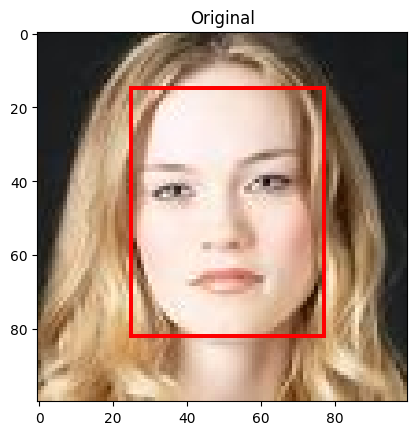

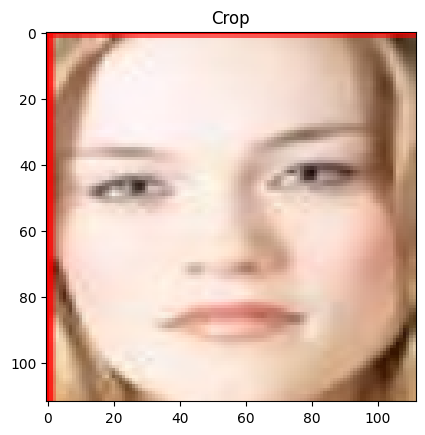

crop has shape torch.Size([3, 112, 112])
Right before arcface crop has shape  torch.Size([2, 3, 112, 112])
rescaled crop has shape (67, 52, 3)
original image has shape (100, 100, 3)
xrange: 52


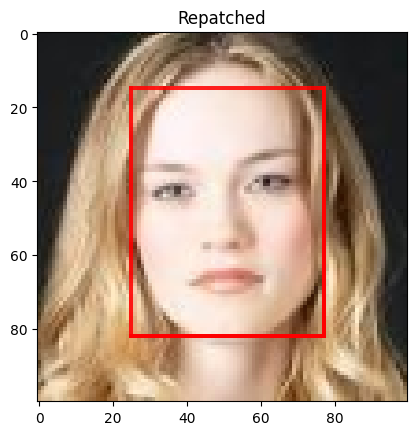

box: [[25.69470977783203 18.188268661499023 78.00242614746094
  85.03868865966797]]


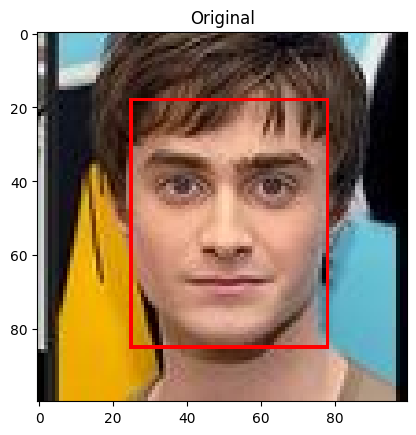

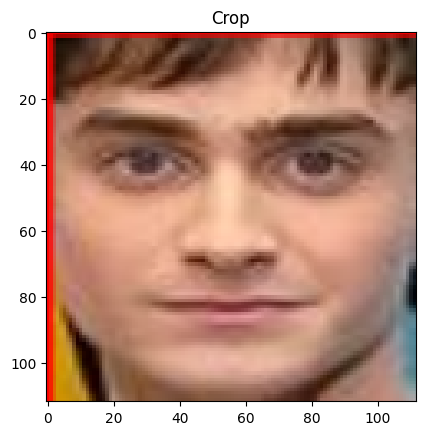

crop has shape torch.Size([3, 112, 112])
Right before arcface crop has shape  torch.Size([2, 3, 112, 112])
rescaled crop has shape (67, 53, 3)
original image has shape (100, 100, 3)
xrange: 53


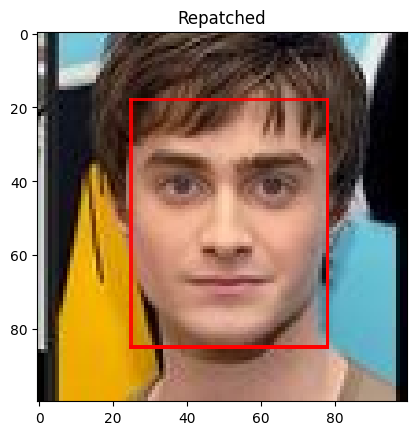

tensor(0.3468, grad_fn=<LinalgVectorNormBackward0>)


In [131]:
save1 = get_out("data/pubfig_flat/Julia Stiles_100.jpg")[0][:] 
save2 = get_out("data/pubfig_flat/Daniel Radcliffe_100.jpg")[0][:]
# print(save1)
# print(save2)
print(torch.linalg.vector_norm(save1 - save2, ord=2))

In [5]:
print("Crop requires grad:", crop.requires_grad)
loss = torch.sum(out)
print("Loss:", loss)
loss.backward()
print("Grad:", crop.grad)

Crop requires grad: True
Loss: tensor(-0.0650, grad_fn=<SumBackward0>)
Grad: tensor([[[[-7.2784e-05,  3.2593e-05,  5.7684e-06,  ..., -9.5910e-06,
           -8.1798e-06, -3.0741e-06],
          [-4.3783e-05,  1.1826e-04,  1.9427e-04,  ..., -2.4816e-05,
           -1.3553e-05, -2.3412e-06],
          [-4.5600e-05,  5.6732e-05,  1.6423e-04,  ..., -3.0403e-05,
           -5.1965e-06,  2.3856e-07],
          ...,
          [ 2.8837e-05,  6.2918e-05, -3.4197e-05,  ..., -2.5009e-04,
            9.1311e-05,  3.2781e-05],
          [ 1.5553e-05,  3.0784e-05, -5.7402e-05,  ..., -9.6622e-05,
           -3.0813e-05, -7.0605e-06],
          [ 2.7829e-05,  2.0388e-05, -1.8038e-05,  ..., -4.2040e-05,
           -6.4268e-06,  8.4778e-06]],

         [[-2.6049e-04, -8.0614e-05,  1.0182e-04,  ..., -2.6604e-05,
           -3.3371e-05, -1.8577e-05],
          [-1.8448e-04,  1.2855e-04,  5.1321e-04,  ..., -6.0044e-05,
           -5.2221e-05, -1.5203e-05],
          [-1.2615e-04,  6.6383e-05,  4.3234e-04, 

None
